<div style="padding:30px; color: white; background-color: #0071CD">
<center>
<img src="img/logoub.jpeg"></img>
<center>
<h1>Algorísmica Avançada 2022</h1>
<h2>Pràctica 2 - Exploració: Grafs, DFS, BFS, Dijkstra</h2>
</center>
</div>

In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

<div class="alert alert-info">
<h2>Avís general per a les Pràctiques de Laboratori</h2>

És molt important <b>comentar tot el vostre codi</b>. Comentar el codi no només facilita a altres persones que el llegeixin la compressió del que esteu fent, sinó també a vosaltres mateixos durant el procés de disseny i implementació. D'aquesta forma podreu entendre el vostre propi codi encara que faci molt temps que no el consulteu. A més, a l'hora de ser corregits, un codi comentat s'entén molt millor, la qual cosa ajuda a traslladar al professor les idees que teníeu a l'intentar implementar-lo i encara més en el cas que no ho hagueu pogut acabar-ho amb èxit. No cal comentar cada línia, però si el que fa cada part.

En segon lloc, és molt important <b>respectar les capçaleres de les funcions i estructura de la funció ```return```</b> que s'indiquin a l'enunciat. Tot i que llegim i corregim els vostres codis en detall, fem servir correctors automàtics per guiar i agilitzar el procés i saber quines solucións funcionen i quines no ja d'entrada. 

Axí doncs, si es demana que la funció tingui la següent estructura: 

```python
def exercici1(param1, param2):
    # implementació de la solució
    return resultat 
```

És important que en el notebook existeixi aquesta funció i que no canvieu el nom dels paràmetres ni el tipus de dada retornada.
    
</div>




<div class="alert alert-warning">
<h2>Sobre la correcció d'aquesta pràctica...</h2>
Com veureu a la capçalera de cada exercici, tots ells tenen una puntuació màxima de 2.5 punts. En tots, es valoraran aquests quatre aspectes:
    <ol>
        <li> El codi <b>s'executa correctament</b>, és a dir, retorna la solució demanada.
        <li> El codi és <b>eficient</b>, és a dir, no fa més càlculs dels necessaris.
        <li> El codi està <b>ben comentat</b>. No cal comentar cada línea de codi però si que es necessari que expliqueu què s'està fent als diferents blocs.
        <li> Les preguntes dels exercicis que en tenen estan respostes i la solució és correcta.
    </ol>
</div>




## maze.py

La llibreria auxiliar ```maze.py```, conté les funcions necessàries per crear i dibuixar laberints aleatoris. A continuació destaquem les funcions més rellevants tot i que podeu obrir el fitxer i investigar.

- ```Maze(x_num, y_num, seed=None, p_down=0.2, p_build=0)```: Aquesta funció construeix i retorna un laberint aleatori de dimensió $x_\text{num} \times y_\text{num}$. El paràmetre $\textit{seed}$ permet fixar una llavor de forma que sempre es generi el mateix laberint. És interessant que, un cop hagueu programat la solució dels exercicis, proveu de modificar-lo per veure que funciona en diferents casos. Els paràmetres $p_\text{down}$ i $p_\text{build}$ són probabilitats de destrucció d'una paret o de construcció. Així, si $p_\text{down}$ és proper a 1, s'eliminen gairebé totes les parets del laberint, creant molts camins entre totes les cel·les. En canvi, si $p_\text{build}$ és proper a 1, es crearan parets que faran que el laberint no tingui solució per a gairebé cap parella de cel·les.

- ```maze.display_maze(height=200, plot_path=False)```: Com el seu nom indica, ens mostra el laberint que hem creat. Podem definir l'alçada del dibuix i l'amplada s'ajusta automàticament. Com veurem, podem assignar un camí a cada laberint. Si hi ha un camí assignat, el podem mostrar cridant la funció amb la variable _plot\_path = True_.

- ```maze.maze_graph()```: Aquesta funció, que no rep cap paràmetre per entrada, ens retorna un graf de la classe nx.Graph() que representa el laberint.

- ```maze.set_path(path)```: Donat un camí definit com una sequència de nodes, el podem assignar al laberint usant aquesta funció. Recorda que si vols visualitzar un camí assignat, pots fer-ho cridant a ```display_maze(plot_path=True)```.

In [4]:
from matplotlib import pyplot as plt
import networkx as nx
from maze import *

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Creem un laberint amb X cel·les horitzontals i Y cel.les verticals i el mostrem.
# Observeu que hem definit un 'seed'. Això vol dir que, tot i que el laberint es genera de forma aleatòria,
# tindreu tots el mateix.
maze = Maze(30, 10, seed=17)
maze.display_maze(height=200)

NameError: name 'Maze' is not defined

La longitud del camí mínim és 53


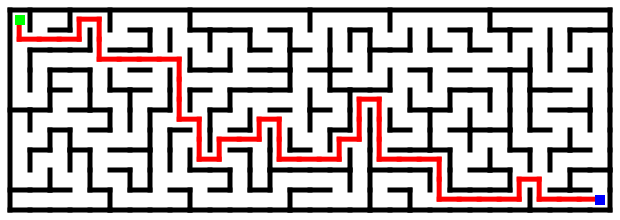

In [ ]:
# Obtenim el graph associat al laberint on cada node es una cel·la i tindrem una aresta si entre dues cel·les no existeix paret
G = maze.maze_graph()

# La llibreria networX ja té una funció per trobar el camí mínim
A = 0                              # Node orígen (Verd) 
B = len(G.nodes)-1                 # Node destí  (Blau)
pth = nx.shortest_path(G, A, B)
print('La longitud del camí mínim és',len(pth))

# Afegim aquest camí al nostre laberint
maze.set_path(pth)

# Mostrem el resultat
maze.display_maze(plot_path=True, height=200)

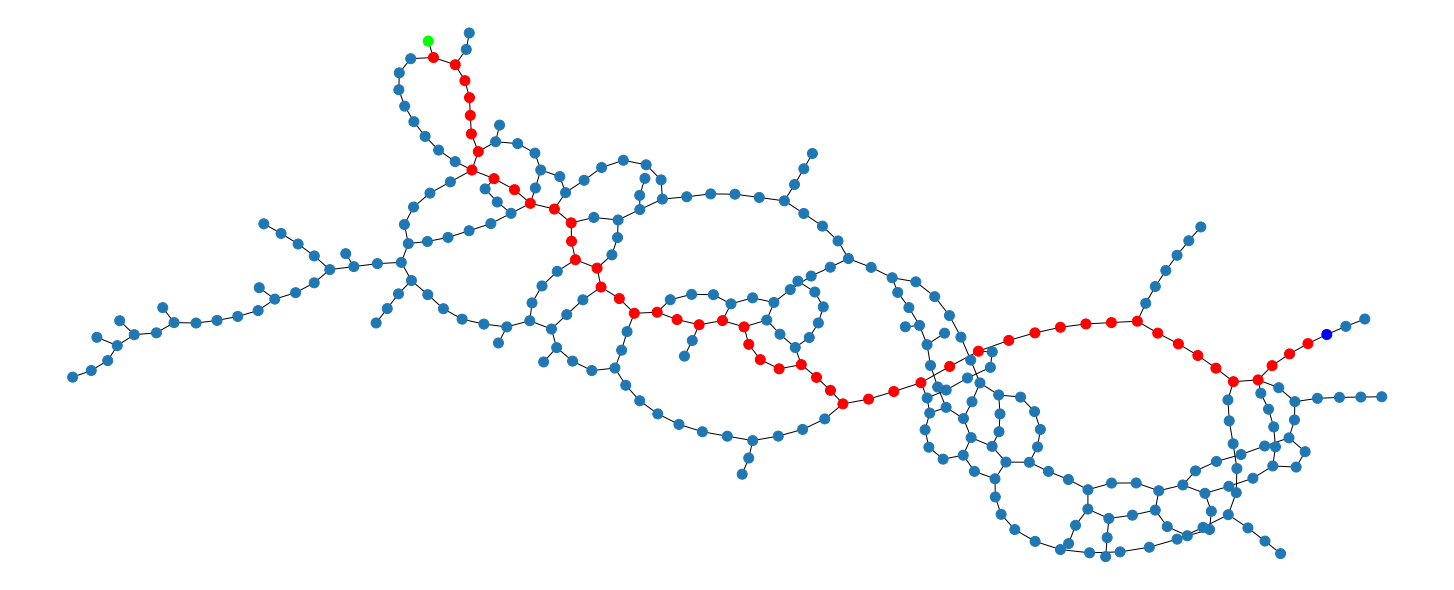

In [ ]:
# Mostrem el laberint com un graf.
plt.figure(figsize=(20,8))

# Definim el color dels nodes.
# Si el node és el punt A (inici) el pintem verd, si es el node B (final) el pintem blau, si es un node del camí, vermell i finalment
# deixem el color per defecte de networkx per a la resta de nodes.

colorA, colorB, colorPTH, colorDEF = '#00ff00', '#0000ff', '#ff0000', '#1f78b4'
color_map = [colorA if n==A else colorB if n==B else colorPTH if n in pth else colorDEF for n in G.nodes]

# Existeixen moltes formes diferents de dibuixar els graphs. La Kamada-Kawai ens permet veure el graf com un 'graf de força'.
# Aquests tipus de visualitzacions intenten que les arestes no se superposin.
pos = nx.kamada_kawai_layout(G).items()

# Com que estem dibuixant en horitzontal, canviem les coordenades x i y de cada punt.
pos = {k: v[::-1] for k,v in pos}

# Dibuixem el graf definint la posició, el color i la mida de cada node.
nx.draw(G, pos=pos, node_color=color_map, node_size=100)

<div class="alert alert-success">
<h1>Problema 1: BFS (2.5p)</h1>
<p>
    Implementeu l'algorisme <b>BFS</b>. Donat un graf de la llibreria networX, la funció <b>bfs()</b> ha de retornar el nombre de caselles accessibles des del paràmetre <b>origin</b>, incloent-hi aquesta. És a dir, la llista retornada sempre inclourà, com a mínim, el node orígen.<br>
    Recordeu que és necessari <b>no canviar l'estructura de la funció</b>. No canvieu ni el nom de la funció, ni el nom dels paràmetres d'entrada ni els de sortida. <br>
</p>    
    
</div>

In [ ]:
def bfs(G, origin):
    """
    Params
    ======    
    :G: Graf. Ha de ser un objecte de la classe nx.Graph
    :origin: Índex del node orígen
    
    Returns
    =======
    :visited: El conjunt de nodes visitats durant l'exploració BFS
    """
    visited = []
    novisitats =[origin]
    #Fem un bucle que acturarà mentre la llista de nodes novisitats no sigui buïda.
    #En aquest cas, el que fem al bucle és que treiem el primer node de novisitats i si no l'hem visitat,
    #llavors s'afegeix a la llista de visitats i es fa una llista amb els seus veïns, i es procedirà a afegir
    #aquests veïns a la llista de novisitats. Això té un final, ja que en certs nodes veurem que els seus veïns
    #ja hauran estat visitats prèviament.
    while novisitats:
        node = novisitats.pop(0);
        if node not in visited:
            visited.append(node)
            neighbours = list(G.adj[node])
            for x in neighbours:
                novisitats.append(x)
    return visited

Des de la cel·la 24 podem accedir a 28 caselles
Ordre d'exploració: [24, 23, 31, 16, 15, 22, 14, 21, 7, 28, 8, 0, 35, 1, 36, 2, 37, 38, 45, 46, 44, 39, 43, 40, 42, 47, 48, 41]


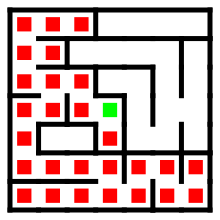

In [ ]:
# Obtenim el graph associat al laberint on cada node es una cel·la i tindrem una aresta si entre dues cel·les no existeix paret
maze = Maze(7, 7, p_build=0.2, seed=18)
G = maze.maze_graph()

A = 24                      
visited = bfs(G, A)
num = len(visited)

print(f"Des de la cel·la {A} podem accedir a {num} caselles")
print(f"Ordre d'exploració: {visited}")
maze.set_values(visited, 1, color=(255,0,0))
maze.set_value(A, 1, color=(0,255,0))

maze.display_maze(plot_path=True, height=200)

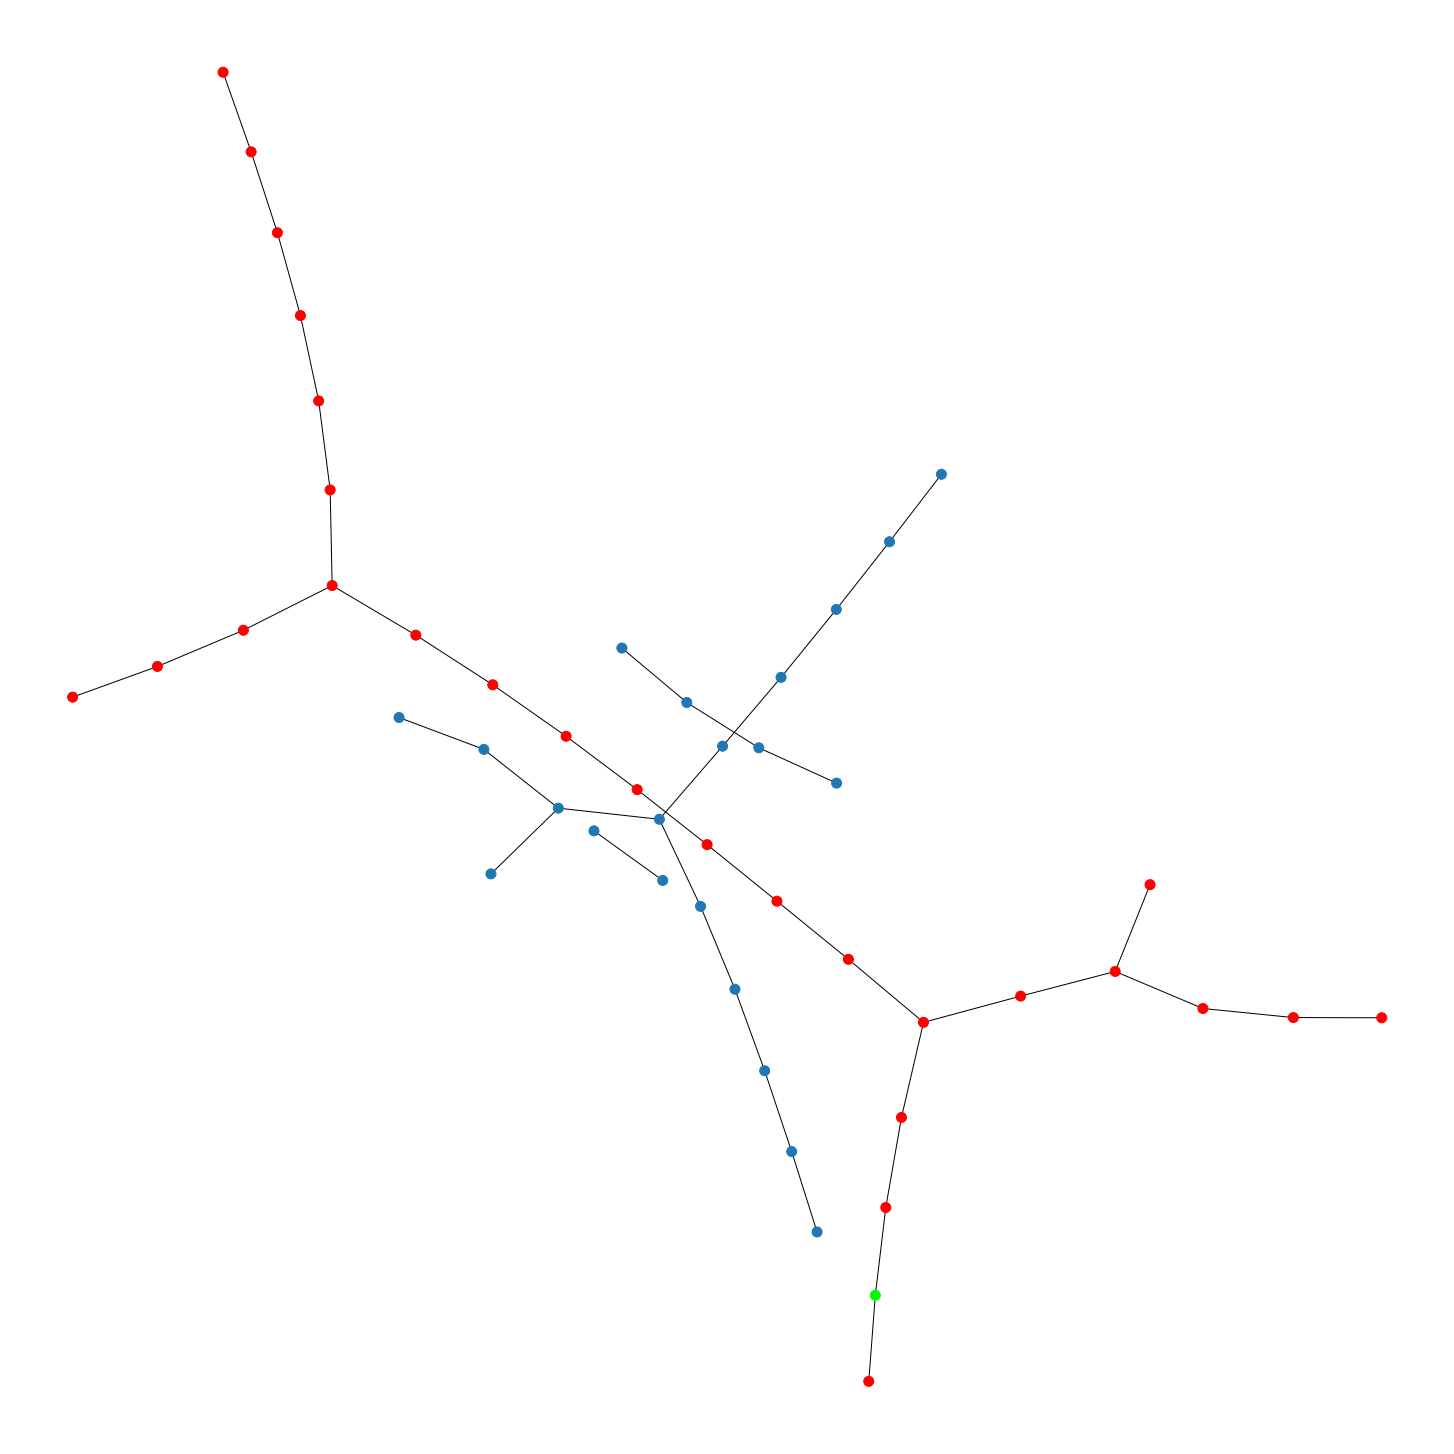

In [ ]:
# Mostrem el laberint com un graf.
plt.figure(figsize=(20,20))

# Definim el color dels nodes.
# Si el node és el punt A (inici) el pintem verd, si es el node B (final) el pintem blau, si es un node del camí, vermell i finalment
# deixem el color per defecte de networkx per a la resta de nodes.
pth = visited
colorA, colorB, colorPTH, colorDEF = '#00ff00', '#0000ff', '#ff0000', '#1f78b4'
color_map = [colorA if n==A else colorB if n==B else colorPTH if n in pth else colorDEF for n in G.nodes]

# Existeixen moltes formes diferents de dibuixar els graphs. La Kamada-Kawai ens permet veure el graf com un 'graf de força'.
# Aquests tipus de visualitzacions intenten que les arestes no se superposin.
pos = nx.kamada_kawai_layout(G).items()

# Com que estem dibuixant en horitzontal, canviem les coordenades x i y de cada punt.
pos = {k: v[::-1] for k,v in pos}

# Dibuixem el graf definint la posició, el color i la mida de cada node.
nx.draw(G, pos=pos, node_color=color_map, node_size=100)

Des de la cel·la 174 podem accedir a 146 caselles
Ordre d'exploració: [174, 124, 173, 175, 123, 172, 223, 225, 73, 222, 273, 226, 272, 221, 323, 227, 322, 171, 324, 228, 121, 170, 274, 229, 122, 71, 120, 169, 224, 279, 72, 21, 70, 119, 168, 329, 22, 20, 69, 218, 330, 23, 19, 68, 280, 331, 24, 18, 118, 67, 281, 332, 74, 17, 117, 66, 282, 231, 333, 75, 16, 167, 230, 232, 334, 25, 15, 217, 180, 182, 284, 26, 14, 267, 181, 130, 183, 283, 27, 64, 13, 268, 131, 80, 233, 133, 77, 65, 63, 269, 132, 79, 234, 127, 113, 219, 319, 129, 78, 184, 235, 177, 163, 220, 318, 320, 179, 134, 285, 176, 162, 213, 317, 270, 178, 135, 286, 112, 263, 214, 316, 271, 128, 85, 236, 111, 315, 321, 35, 161, 34, 211, 33, 210, 261, 209, 260, 262, 311, 159, 259, 310, 212, 312, 160, 313]


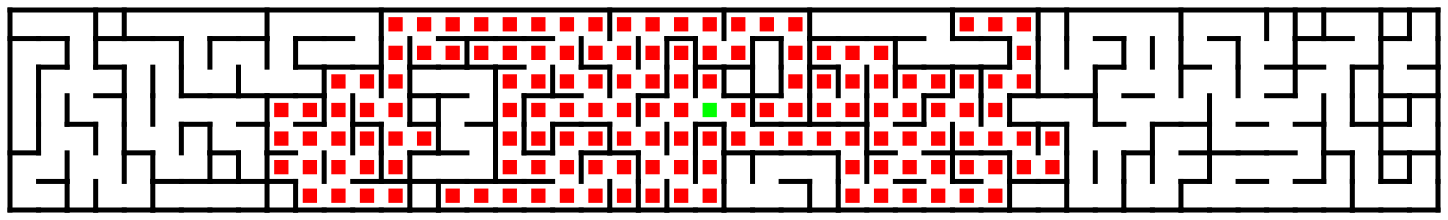

In [ ]:
# Obtenim el graph associat al laberint on cada node es una cel·la i tindrem una aresta si entre dues cel·les no existeix paret
maze = Maze(50, 7, p_build=0.2, seed=18)
G = maze.maze_graph()

A = 174                      
visited = bfs(G, A)
num = len(visited)

print(f"Des de la cel·la {A} podem accedir a {num} caselles")
print(f"Ordre d'exploració: {visited}")
maze.set_values(visited, 1, color=(255,0,0))
maze.set_value(A, 1, color=(0,255,0))

maze.display_maze(plot_path=True, height=200)

<div class="alert alert-success">
<h1>Problema 2: Holes (2.5p)</h1>
<p>
    Implementeu una funció anomenada <b>holes()</b> que, donat un graf, un node orígen, un node destí, una llista de nodes i un paràmetre enter, trobi el camí més curt entre orígen i destí. <br>
    Si el camí passa per un dels nodes de la llista, se li aplicarà una penalització.<br>
    Heu de basar la vosta solució en l'algorisme <b>Dijkstra</b>.
</p>    
    
</div>

In [ ]:
import heapq

In [ ]:
def dijkstra(G, nodes, origin, holes_list, penalty=50):
    #Aquesta funció serà una funció auxil·liar que ens permetrà estalviar-nos part de codi i
    #disminuir la complexitat en certs casos. Aquesta funció és la implementació de l'algorisme
    # de Dijkstra.
    # Aquesta implementció de l'algorisma de Dijkstraa fet ús d'un binary heap té complexitat (V + E)log(V)
    # Diccionari que guardarà les distàncies cap a cada node respecte el node origin
    distancia = {} 
    
    # Diccionari que per cada node gaurdarà el seu previ en el camí
    prev = {} 
    # Passant el holes_list d'una llista a un set, fem que el fet de consultar els nodes sigui de O(1) en comptes de O(n).
    holes_set = set(holes_list)
    # Utilitzarem el heap per guardar tuples de (distància, node), on la distància és respecte
    # origin. Cada element del heap és una tupla.
    heap = [] 
    
    # Farem aquest for per inicialitzar els diccionaris, amb distàncies d'infinit respecte origin per defecte.
    # A més a més, posarem com a None el previ de cada node.
    for node in nodes:
        distancia[node] = float('inf')
        prev[node] = None
        
    # Afegim primer element del heap.
    heapq.heappush(heap, (0, nodes[origin])) 
    distancia[nodes[origin]]= 0
    
    # És l'inici del camí, així que no tindrà previ.
    prev[nodes[origin]] = None 
    while(len(heap) != 0):
        
        # Eliminem l'element del heap i el guardem en una variable per poder accedir als seus veïns
        u =heapq.heappop(heap)
        
        # Donat que cada element del heap és una tupla, volem accedir al segon component de la tupla,
        # que és un node ( u[1]), per tal de tractar amb el node i no amb la distància respecte origin (u[0])
        for neighbour in G.neighbors(u[1]):
            if neighbour not in holes_set:
                alt = distancia[u[1]] + 1
            else: 
                alt = distancia[u[1]] + penalty 
                
            # Si el cost del node que estem tractant és inferior al del seu veï, anomenarem el previ del veï com
            # el node actual amb el que s'està treballant.
            if alt < distancia[neighbour]:
                distancia[neighbour] = alt
                prev[neighbour]= u[1]
        
                # Afegim una tupla al heap, que consisteix en el cost del node actual i el node veï.
                heapq.heappush(heap, (alt, neighbour))
    return prev, distancia

In [ ]:
def holes(G, origin, destination, holes_list=[], penalty=50):
    """
    Params
    ======
    :G: Graf del qual en volem extreure el camí mínim. Ha de ser un objecte de la classe nx.Graph
    :origin: Índex del node orígen
    :destination: Índex del node destí
    :holes_list: Una llista de punts que tindran penalització
    :penalty: Valor enter de penalització
    
    Returns
    =======
    :path: Una llista de nodes del camí més curt entre els nodes 'origin' i 'destination' (ambdós inclosos) que passa per tots els nodes 'extras'.
    """
    path = []
    nodes = list(G.nodes)
    
    # Com que tenim un diccionari de prev retornat pel dijkstra, llavors el node inicial per formar la llista
    # serà el destination, que és el final del camí
    v = nodes[destination]
    prev_i_dist = dijkstra(G, nodes, origin, holes_list, penalty)
    
    # El bucle es mantindrà fins arribar a l'inici del camí, mitjançant la crida del prev[v]. Per cada crida, s'afegeix
    # el node en qüestió al path. En aquest cas, com que dijkstra ens retorna dos diccionaris, volem accedir al primer 
    # dels diccionaris, i dins d'aquest accedir al prev del node v. La crida dels prev serà, per tant: prev_i_dist[0][v].
    while v != nodes[origin]:
        path.append(v)
        v = prev_i_dist[0][v]
    
    # Cal fer aquest append, ja que el bucle s'atura justa quan v = nodes[origin], i per tant no l'està afegint.
    path.append(nodes[origin])
    # Com hem anat des del final a l'inici, cal girara la llista que hem obtingut.
    path.reverse()
    return path

Penalització: 2
Longitud del camí: 53


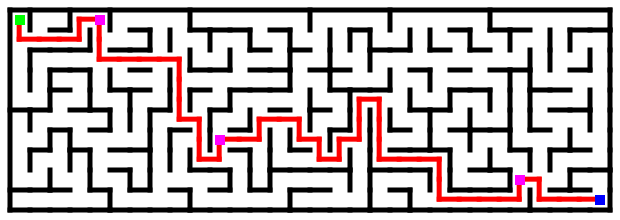

Penalització: 5
Longitud del camí: 57


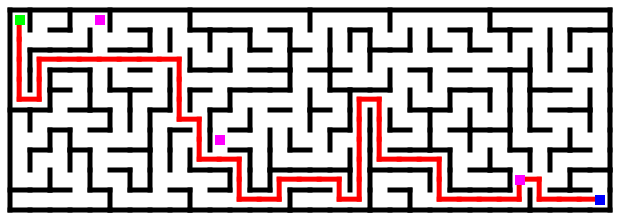

Penalització: 10
Longitud del camí: 63


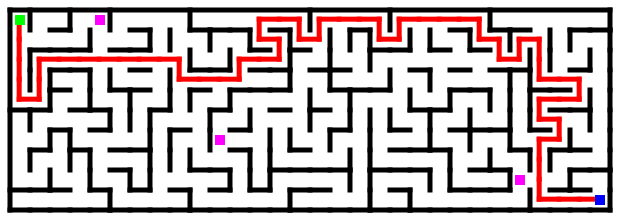

In [ ]:
# Proveu el vostre algorisme!

maze = Maze(30, 10, seed=17)

# Obtenim el graph associat al laberint on cada node es una cel·la i tindrem una aresta si entre dues cel·les no existeix paret
G = maze.maze_graph()

A = 0
B = len(G.nodes)-1
holes_list = [4, 190, 265]
color = (255, 0, 255)

penalties = [2,5,10]
for v in penalties:
    maze.set_values(holes_list, 1, color)
    path = holes(G, A, B, holes_list, v)
    
    maze.set_path(path)
    print(f"Penalització: {v}")
    print('Longitud del camí:', len(path))
    maze.display_maze(plot_path=True, height=200)

    maze.set_values(holes_list, 0, color)

<div class="alert alert-success">
<h1>Problema 3: Checkpoint (2.5p)</h1>
<p>
    Implementeu una funció anomenada <b>checkpoint()</b> que, donat un graf, un node origen, un node destí i un node extra, trobi el camí més curt des del node origen fins el node destí passant pel node extra. Com en l'exercici anterior, tindrem una llista de punts on aplicarem una penalització.<br>
</p>    
    
</div>

<div class="alert alert-warning">
<p>
    Quina és la complexitat d'aquest algorisme?</b><br>
</p>    

 << O((V + E)*log(V))
 
 (Valor de la complexitat especificada en el codi) >>
    
</div>

In [ ]:
def checkpoint(G, origin, destination, extra, holes_list=[], penalty=50):
    """
    Params
    ======
    :G: Graf del qual en volem extreure el camí mínim. Ha de ser un objecte de la classe nx.Graph
    :origin: Índex del node orígen
    :destination: Índex del node destí
    :extra: Índex d'un node extra per on ha de passar el camí
    :holes_list: Una llista de punts que tindran penalització
    :penalty: Valor enter de penalització
    
    Returns
    =======
    :path: Una llista de nodes del camí més curt entre els nodes 'origin' i 'destination' que passa per 'extra'.
    =======
    COMPLEXITAT: T_Dijkstra + V + V = (V + E)*log(V) + 2V => O((V + E)*log(V))
    V: Nombre de nodes
    E: Nombre d'arestes
    """
    path = [] 
    
    # En tenir un node extra pel qual hem de passar obligatòriament, el que farem serà fer una llista
    # des d'origin al node extra i una altra des del node extra fins el destination. Per això, només
    # caldrà tenir una llista auxil·liar, que farà des d'origin al checkpoint.
    pathorigtocheck = []
    nodes = list(G.nodes)
    
    # Com que tenim el node extra com a node de referència per calcular els prev i les distàncies, en 
    # comptes de cridar al dijkstra del node origin, el cridem pel node extra.
    prev_i_dist = dijkstra(G, nodes, extra, holes_list, penalty)
    v = nodes[destination]
    
    # Ara el que farem és la llista des del node extra fins el destination.
    # Notem que com al holes, per accedir al prev fem servir el diccionari prev que ens retorna el dijkstra.
    # Per tant, es cridarà al prev com prev_i_dist[0][v].
    while v != nodes[extra]:
        path.append(v)
        v = prev_i_dist[0][v]
    path.reverse()
    # I a continuació, utilitzarem la llista auxil·liar per fer des del origin fins extra.
    v = nodes[origin]
    while v != nodes[extra]:
        pathorigtocheck.append(v)
        v = prev_i_dist[0][v]
        
    # Cal fer aquest append, ja que el bucle s'atura justa quan v = nodes[origin], i per tant no l'està afegint.
    pathorigtocheck.append(nodes[extra])
    
    # Ara, per juntar les dues llistes i que ens quedi el path complet, li sumem per la banda esquerra el pathorigtocheck
    # i ens quedarà la llista path ben ordenada.
    path = pathorigtocheck + path
    return path

Penalització: 2
La distàcia del camí més curt que passa per E és: 11
El camí és: [0, 6, 12, 13, 19, 20, 21, 22, 28, 29, 35]


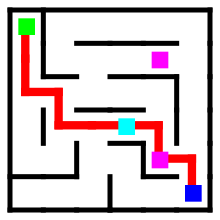

Penalització: 5
La distàcia del camí més curt que passa per E és: 13
El camí és: [0, 6, 12, 13, 19, 20, 21, 20, 26, 27, 33, 34, 35]


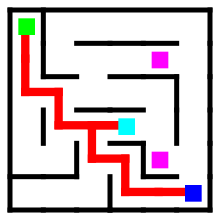

In [ ]:
# Proveu el vostre algorisme!

# Creem un laberint i n'extraiem el graph
maze = Maze(6,6, seed=17)
G = maze.maze_graph()

# Definim l'inici, el fi, un node extra i la llista amb penalització
A = 0
B = len(G.nodes)-1
E = 21
holes_list = [10, 28]
penalties = [2, 5]

for penalty in penalties:
    # La funció set_value ens permet 'activar' un node per a que surti dibuixat al laberint.
    maze.set_value(E, 1)                         # Checkpoint
    maze.set_values(holes_list, 1, (255,0,255))  # Penalitzacions

    path = checkpoint(G, A, B, E, holes_list, penalty)
    print(f'Penalització: {penalty}')
    print('La distàcia del camí més curt que passa per E és:', len(path))
    print(f'El camí és: {path}')
    maze.set_path(path)
    maze.display_maze(plot_path=True, height=200)
    
    maze.set_value(E, 0)                         # Checkpoint
    maze.set_values(holes_list, 0, (255,0,255))  # Penalitzacions

<div class="alert alert-success">
<h1>Problema 4: Checkpoints list (2.5p)</h1>
<p>
    Implementeu una funció anomenada <b>checkpoints_list()</b> que, donat un graf, un node origen, un node destí i una llista de nodes extres, trobi el camí més curt des del node origen fins el node destí passant per tots els nodes extra, en qualsevol ordre. Com en l'exercici anterior, tindrem una llista de punts on aplicarem una penalització.<br>
</p>    
    
</div>

<div class="alert alert-warning">
<p>
    Quina és la complexitat d'aquest algorisme?</b><br>
</p>    

 << O(Extras*Extras!)
 
 (Valor de la complexitat especificat en el codi) >>
    
</div>

In [ ]:
from itertools import permutations

In [ ]:
def checkpoints_list(G, origin, destination, extras, holes_list=[], penalty=50):
    """
    Params
    ======
    :G: Graf del qual en volem extreure el camí mínim. Ha de ser un objecte de la classe nx.Graph
    :origin: Índex del node orígen
    :destination: Índex del node destí
    :extras: Llista d'índexs de nodes per on ha de passar el camí.
    :holes_list: Una llista de punts que tindran penalització
    :penalty: Valor enter de penalització
    
    Returns
    =======
    :path: Una llista de nodes del camí més curt entre els nodes 'origin' i 'destination' que passa per tots els nodes 'extras'.
    COMPLEXITAT = Extras*T_Dijkstra + Extras!*Extras + V + V = Extras*((V+E)*log(V)) + Extras!*Extras + 2V = Extras!*Extras => O(Extras*Extras!)
    V: Nombre de nodes del graf
    E: Nombre d'arestes del graf
    Extras: Nombre de nodes extras
    """ 
    path = []
    
    # Crearem un diccionari que tindrà tants elements com nodes extras. Per cada key (node) es guardarà 
    # una tupla de dos diccionaris (els que retorna dijkstra).
    prevdistNodes ={}
    nodes = list(G.nodes)
    
    # Aqui estem afegint elements (nodes) al diccionari. 
    # Amb aquesta implementació, ens estalviem cridar al dijkstra n! vegades, amba n el nombre de nodes extras.
    # Per tant, només l'estem cridant 4 vegades fora del for de les permutacions.
    for e in extras:
        prevdistNodes[e] = dijkstra(G, nodes, e, holes_list, penalty)
        
    # Utilitzem la funció permutations per poder fer totes les combinacions possibles dels nodes extras.
    permutacions = list(permutations(extras)) 
    
    distancia = float('inf') # Distància inicial del camí per defecte.
    min_perm = None          # Permutació que compleix la mínima distància. 
    
    # De la llista de permutacions, per cada permutació d'aquestes farem un "nou camí". La diferència és 
    # que només haurem de consultar el diccionari, i no haurem d'utilitzar dijkstra, cosa que abarateix
    # molt el cost. En realitat, en comptes de tenir un nou camí, es calcularà la distància total per cada
    # combinació de nodes extras, juntament amb origin i destination que romanen fixos com primer i últim node
    # del camí, respectivament.
    # La complexitat d'aquest bloc de codi és del extras!* extras, ja que tenim extras! permutacions i les recorrem cadascuna d'aquestse. La llargada
    # d'una permutació dependrà de la llargada de la llista d'extras.
    for permutacio in permutacions:
        nodeaux = origin 
        distancia_aux = 0
        
        # Per cada node de la permutació, agafarem el nodeaux i buscarem la seva distància des del node actual.
        # al final del codi d'aquest for, fem que nodeaux passi a ser el node actual, de forma que a la següent
        # iteració, el nodeaux ja sigui el primer d'aquesta permutació i el node actual sigui el segon
        for node in permutacio:
            distancia_aux += prevdistNodes[node][1][nodeaux]
            nodeaux = node
        distancia_aux += prevdistNodes[nodeaux][1][destination]
        
        # Un cop tenim tota la distància del camí donat per aquesta permutació, comparem amb la distancia mínima ( distancia.
        # Si la distància del camí (distanci_aux) és inferior a la mínima, llavors actualitzem la distància mínima i guardem
        # aquesta permutació com la permutació que ens proporciona el camí més curt.
        if distancia > distancia_aux:
            distancia = distancia_aux
            min_perm = permutacio
    
    nodeaux = nodes[destination]
    
    # Aquest bucle for recorre la llista de la permutació escollida en ordre invers, de forma que permet utilitzar el diccionari prev que ens proporciona
    # el dijkstra.
    # La llargada del path no la sabem, ja que depèn de l'origin, destination i la llista de nodes extras. Per tant, com a molt aquest bloc té 
    # complexitat V pel funcionament del Dijkstra.
    
    for node in range(len(min_perm)-1,-1, -1):
        
        # Seguint el mateix procediment que en els exercicis anteriors, anirem cridant als prev a partir del diccionari, tal que accedirem a la key del 
        # node corresponent a la iteració del for i accedirem a l'índex 0 de la tupla que guarda, corresponent al diccionari prev.
        while nodeaux != min_perm[node]:
            path.append(nodeaux)
            nodeaux = prevdistNodes[min_perm[node]][0][nodeaux] 
    path.reverse()
    auxpath = []
    nodeaux = nodes[origin]
    
    # Com que no tenim una key d'origin, el que farem és crear una llista auxil·liar que guardarà els elements des d'origin fins el primer node de la
    # permutació en l'ordre correcte. Per tant, no caldrà fer ús de .reverse()
    while nodeaux != min_perm[0]:
        auxpath.append(nodeaux)
        nodeaux = prevdistNodes[min_perm[0]][0][nodeaux]
    auxpath.append(min_perm[0])
    path = auxpath + path
    return path   

In [ ]:
# Proveu el vostre algorisme!

# Creem un laberint i n'extraiem el graph
maze = Maze(30, 10, seed=17)
G = maze.maze_graph()

# Definim l'inici, el fi i node extres
A = 0
B = len(G.nodes)-1
E = [286, 201, 16, 68]
holes_list = [158, 164, 167]
penalties = [1, 10, 20]

for penalty in penalties:
    # La funció set_values ens permet 'activar' nodes per a que surtin dibuixat al laberint.
    maze.set_values(E, 1)                        # Checkpoint
    maze.set_values(holes_list, 1, (255,0,255))  # Penalitzacions

    path = checkpoints_list(G, A, B, E, holes_list, penalty)
    print(f'Penalització: {penalty}')
    print('La distància del camí més curt que passa per E és:', len(path))
    maze.set_path(path)
    maze.display_maze(plot_path=True, height=200)

    # De la mateixa forma la funció set_values també ens permet 'desactivar' els nodes.
    maze.set_values(E, 0)
    maze.set_values(holes_list, 0, (255,0,255))

NameError: name 'Maze' is not defined

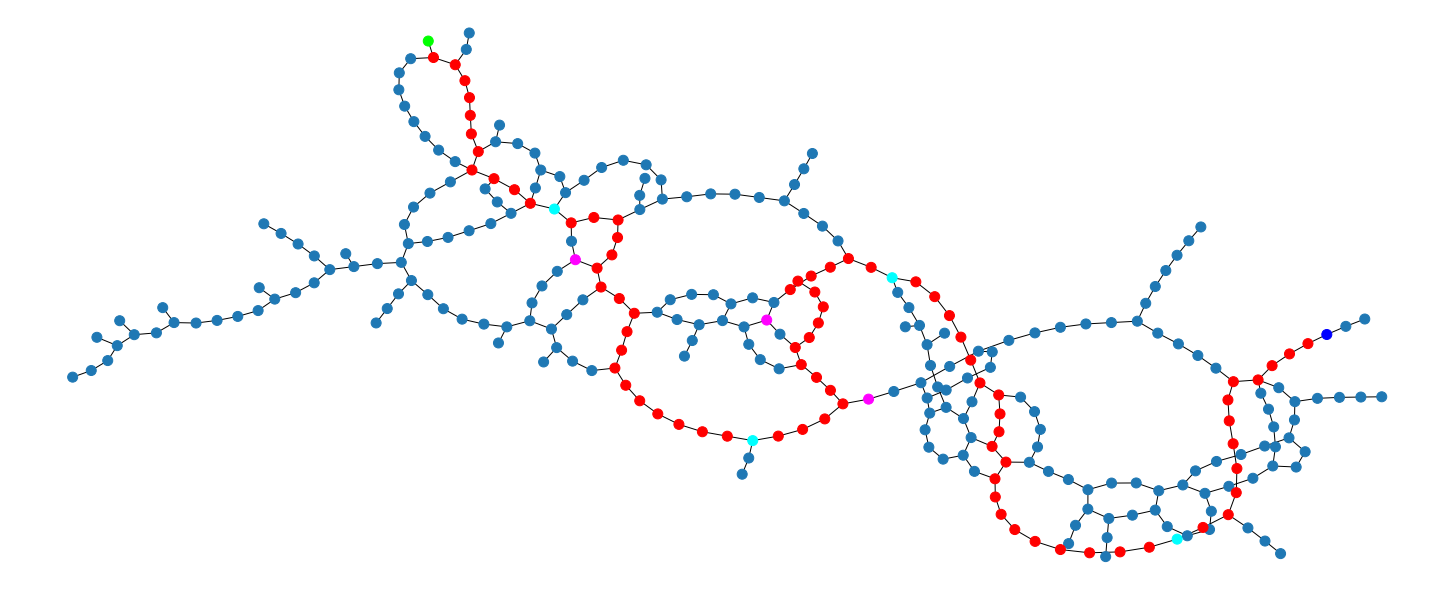

In [ ]:
plt.figure(figsize=(20,8))

colorA, colorB, colorE, colorP, colorPTH, colorDEF = '#00ff00', '#0000ff', '#00ffff', '#ff00ff', '#ff0000', '#1f78b4'
color_map = [colorA if n==A else colorB if n==B else colorE if n in E else colorP if n in holes_list else colorPTH if n in path else colorDEF for n in G.nodes]

pos = nx.kamada_kawai_layout(G).items()

pos = {k: v[::-1] for k,v in pos}

# Dibuixem el graf definint la posició, el color i la mida de cada node.
nx.draw(G, pos=pos, node_color=color_map, node_size=100)

<div class="alert alert-info">
<center>
  <h1>Entrega</h1>
</center>

<p>
L'entrega es farà a través del campus virtual. Teniu fins el dia <b>16 d'Octubre a les 23:55</b> per entregar la pràctica. A la tasca que obrirem al campus, només heu d'entregar aquest fitxer .ipynb (No entregueu maze.py ni cap altre fitxer extra). El notebook ha de tenir com a nom:
</p>
<p>
    <code>Grup_Cognom_Nom_Exploracio.ipynb</code>
</p>
On 'Grup' és una sola lletra que identifica el <b>grup de laboratori</b> on esteu matriculats (A, B, C, D, E, F). 

És imprescindible que respecteu el format de les funcions i que el vostre codi estigui degudament comentat.<br><br>
</div>